# B — Long-horizon Cost Propagation Test

Aの100 geometry/Nデータを固定し、Cost Critic targetだけを **n=1 / 10 / 20 / 50** に変更します。固定Actor、同一Replay、同一Cost Critic初期値、同一update数、共通held-out corpusで比較します。

In [1]:
from pathlib import Path
from copy import deepcopy
import gc, json, platform
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display

ROOT=Path.cwd().resolve()
if not (ROOT/'uav_safe_marl').is_dir(): ROOT=ROOT.parent
SOURCE_RUN=ROOT/'runs'/'mini_pilot_episodic_dcost6_mps'
SOURCE_CHECKPOINT=SOURCE_RUN/'checkpoints'/'final.pt'
A_RUN=ROOT/'runs'/'scenario_diversity_confirmation'
REPLAY_PATH=A_RUN/'C_diversity_fixed_actor_replay.pt'
VALIDATION_PATH=ROOT/'runs'/'scenario_diversity_screening'/'fixed_validation_corpus.pt'
OUTPUT_RUN=ROOT/'runs'/'n_step_cost_propagation'
N_STEPS=[1,10,20,50]
COST_CRITIC_SEEDS=[0,1,2]
UPDATE_MILESTONES=[0,1_000,5_000,10_000,20_000]
REPLAY_CAPACITY=200_000
RETRAIN=False
for p in (SOURCE_CHECKPOINT,REPLAY_PATH,VALIDATION_PATH):
    if not p.exists(): raise FileNotFoundError(f'{p} — A notebookを先に完了してください')
OUTPUT_RUN.mkdir(parents=True,exist_ok=True)
print({'n_steps':N_STEPS,'seeds':COST_CRITIC_SEEDS,'output':str(OUTPUT_RUN)})

{'n_steps': [1, 10, 20, 50], 'seeds': [0, 1, 2], 'output': '/Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/n_step_cost_propagation'}


In [2]:
print({'platform':platform.platform(),'torch':torch.__version__,'mps_available':torch.backends.mps.is_available()})
if not torch.backends.mps.is_available(): raise RuntimeError('VS Codeでプロジェクトの.venvカーネルを選択してください。')
probe=torch.ones((128,128),device='mps'); print({'device':str(probe.device),'probe':float((probe@probe).sum().cpu())}); del probe

{'platform': 'macOS-15.6-arm64-arm-64bit-Mach-O', 'torch': '2.14.0', 'mps_available': True}
{'device': 'mps:0', 'probe': 2097152.0}


In [3]:
from uav_safe_marl import build_env, load_config
from uav_safe_marl.runners.trainer import SafeRLTrainer
resolved=json.loads((SOURCE_RUN/'resolved_config.json').read_text())
resolved['device']='mps'; resolved['learning']['buffer_size']=REPLAY_CAPACITY; resolved['training']['total_environment_steps_budget']=None
resolved['monitoring'].update({'enabled':True,'progress_bar':True,'tensorboard':False,'auto_launch_tensorboard':False,'open_browser':False})
config=load_config(ROOT/'configs'/'full.yaml',overrides=resolved)
assert config.policy.backend.upper()=='SAC' and config.learning.d_cost==6.0
validation_payload=torch.load(VALIDATION_PATH,map_location='cpu',weights_only=False); validation_corpus=validation_payload['corpus']; del validation_payload
print({'gamma_cost':config.learning.gamma_cost,'batch':config.learning.batch_size,'validation_rollouts':len(validation_corpus)})

{'gamma_cost': 0.99, 'batch': 256, 'validation_rollouts': 90}


## 1. 共通初期化・freeze監査
n=1も同じn-step APIを通すため、実装差ではなくtarget horizonだけを比較します。

In [4]:
def module_snapshot(module): return {k:v.detach().cpu().clone() for k,v in module.state_dict().items()}
def frozen_snapshot(t): return {'actor':module_snapshot(t.backend.actor),'reward':module_snapshot(t.backend.reward_critics),'reward_target':module_snapshot(t.backend.reward_targets),'alpha':t.backend.log_alpha.detach().cpu().clone(),'lambda':float(t.backend.dual.value)}
def assert_frozen(t,b):
    for key,module in [('actor',t.backend.actor),('reward',t.backend.reward_critics),('reward_target',t.backend.reward_targets)]: assert all(torch.equal(v,module.state_dict()[k].detach().cpu()) for k,v in b[key].items()),f'{key} changed'
    assert torch.equal(b['alpha'],t.backend.log_alpha.detach().cpu()) and b['lambda']==float(t.backend.dual.value)
def common_initialization(seed):
    path=A_RUN/f'cost_init_seed{seed}.pt'
    if not path.exists():
        d=deepcopy(config.to_dict()); d['seed']=seed; d['monitoring'].update({'enabled':False,'progress_bar':False,'tensorboard':False,'auto_launch_tensorboard':False,'open_browser':False})
        c=load_config(ROOT/'configs'/'full.yaml',overrides=d); init=SafeRLTrainer(c,build_env(c),OUTPUT_RUN/f'initializer_seed{seed}'); torch.save(module_snapshot(init.backend.cost_critics),path); init.env.close()
    return torch.load(path,map_location='cpu',weights_only=False)
def load_arm(n_step,seed):
    t=SafeRLTrainer(config,build_env(config),OUTPUT_RUN/f'n{n_step}_seed{seed}'); t.load_checkpoint(SOURCE_CHECKPOINT,resume_training=False)
    payload=torch.load(REPLAY_PATH,map_location='cpu',weights_only=False); t.buffer.load_state_dict(payload['replay_buffer']); del payload
    initial=common_initialization(seed); t.backend.cost_critics.load_state_dict(initial); t.backend.cost_targets.load_state_dict(initial)
    t.backend.critic_optimizer=torch.optim.Adam(list(t.backend.reward_critics.parameters())+list(t.backend.cost_critics.parameters()),lr=config.policy.learning_rate)
    return t
# Replayの境界処理を実データで監査
probe_trainer=load_arm(1,COST_CRITIC_SEEDS[0])
for n in N_STEPS:
    batch=probe_trainer.buffer.sample_n_step(config.learning.batch_size,n,config.learning.gamma_cost)
    print(n,{'mean_horizon':float(batch['n_step_horizon'].mean()),'min':int(batch['n_step_horizon'].min()),'max':int(batch['n_step_horizon'].max()),'bootstrap_fraction':float(batch['n_step_bootstrap_mask'].mean())})
probe_trainer.env.close(); del probe_trainer; gc.collect(); torch.mps.empty_cache()

1 {'mean_horizon': 1.0, 'min': 1, 'max': 1, 'bootstrap_fraction': 0.99609375}
10 {'mean_horizon': 9.96875, 'min': 7, 'max': 10, 'bootstrap_fraction': 0.98828125}
20 {'mean_horizon': 19.63671875, 'min': 2, 'max': 20, 'bootstrap_fraction': 0.9609375}
50 {'mean_horizon': 48.02734375, 'min': 1, 'max': 50, 'bootstrap_fraction': 0.92578125}


## 2. Calibration関数
Start-stateは全milestone、時間距離別誤差は最終20kのみ評価します。

In [5]:
def rankdata(x):
    x=np.asarray(x,float); order=np.argsort(x,kind='mergesort'); ranks=np.empty(len(x)); i=0
    while i<len(x):
        j=i+1
        while j<len(x) and x[order[j]]==x[order[i]]: j+=1
        ranks[order[i:j]]=(i+j-1)/2+1; i=j
    return ranks
def corr(a,b): return None if len(a)<2 or np.std(a)==0 or np.std(b)==0 else float(np.corrcoef(a,b)[0,1])
def returns_to_go(costs):
    out=np.zeros_like(np.asarray(costs,float)); running=0.0
    for i in range(len(out)-1,-1,-1): running=float(costs[i])+config.learning.gamma_cost*running; out[i]=running
    return out
def lead_bin(lead):
    if lead is None:return 'no_future_cost'
    if lead<=10:return '0-10'
    if lead<=50:return '11-50'
    if lead<=150:return '51-150'
    return '151+'
def evaluate_arm(t,n_step,seed,milestone,temporal=False):
    rr=[]; bins=[]
    for item in tqdm(validation_corpus,desc=f'n{n_step}/seed{seed}@{milestone}',leave=False):
        obs=item['policy_observations']; q=t.backend.start_cost_statistics_for_action(obs[0],item['policy_actions'][0])
        rr.append({'n_step':n_step,'seed':seed,'milestone':milestone,'scenario_id':item['scenario_id'],'actual_agent_count':item['actual_agent_count'],'repeat':item['repeat'],'mc':item['discounted_episode_cost'],'q_ucb':q['ucb']})
        if temporal:
            costs=np.asarray(item['costs'],float); rtg=returns_to_go(costs); positive=np.flatnonzero(costs>1e-12); selected={0}
            for event in positive: selected.update(max(0,int(event)-lag) for lag in (0,10,50,150,300))
            grouped={}
            for index in sorted(selected):
                future=positive[positive>=index]; name=lead_bin(None if not len(future) else int(future[0]-index))
                qs=t.backend.cost_statistics_for_nominal_action(obs[index],item['nominal_actions'][index],held_residual_action=item['held_residual_actions'][index],actor_phase=int(item['actor_phases'][index]))
                grouped.setdefault(name,[]).append(abs(qs['ucb']-rtg[index]))
            for name,values in grouped.items(): bins.append({'n_step':n_step,'seed':seed,'milestone':milestone,'scenario_id':item['scenario_id'],'repeat':item['repeat'],'lead_bin':name,'trajectory_mae':float(np.mean(values)),'state_count':len(values)})
    sr=[]
    for sid in sorted({r['scenario_id'] for r in rr}):
        g=[r for r in rr if r['scenario_id']==sid]; sr.append({'n_step':n_step,'seed':seed,'milestone':milestone,'scenario_id':sid,'actual_agent_count':g[0]['actual_agent_count'],'mc':float(np.mean([r['mc'] for r in g])),'q_ucb':float(np.mean([r['q_ucb'] for r in g]))})
    mc=np.array([r['mc'] for r in sr]); q=np.array([r['q_ucb'] for r in sr]); actual=mc>config.learning.d_cost; pred=q>config.learning.d_cost; tp=int(np.sum(actual&pred)); fn=int(np.sum(actual&~pred)); tn=int(np.sum(~actual&~pred)); fp=int(np.sum(~actual&pred))
    summary={'n_step':n_step,'seed':seed,'milestone':milestone,'scenario_count':len(sr),'mc_mean':float(mc.mean()),'ucb_mean':float(q.mean()),'mae':float(np.mean(abs(q-mc))),'rmse':float(np.sqrt(np.mean((q-mc)**2))),'pearson':corr(mc,q),'spearman':corr(rankdata(mc),rankdata(q)),'false_negative_rate':fn/max(1,tp+fn),'false_positive_rate':fp/max(1,tn+fp),'confusion':{'tp':tp,'fn':fn,'tn':tn,'fp':fp},'coverage':float(np.mean(mc<=q))}
    summary['by_n']={}
    for n in sorted({r['actual_agent_count'] for r in sr}):
        g=[r for r in sr if r['actual_agent_count']==n]; a=np.array([r['mc'] for r in g]); b=np.array([r['q_ucb'] for r in g]); summary['by_n'][str(n)]={'count':len(g),'mc_mean':float(a.mean()),'ucb_mean':float(b.mean()),'mae':float(np.mean(abs(a-b))),'pearson':corr(a,b)}
    if temporal:
        summary['temporal']={}
        for name in ('0-10','11-50','51-150','151+','no_future_cost'):
            values=[]
            for sid in sorted({r['scenario_id'] for r in bins if r['lead_bin']==name}): values.append(float(np.mean([r['trajectory_mae'] for r in bins if r['scenario_id']==sid and r['lead_bin']==name])))
            if values: summary['temporal'][name]={'scenario_balanced_mae':float(np.mean(values)),'valid_scenarios':len(values)}
    return summary,rr,sr,bins

## 3. n-step Cost Critic学習
各armを逐次ロードしてメモリを解放します。Checkpointがあれば再開できます。

In [6]:
def write_jsonl(path,rows):
    with Path(path).open('w') as f:
        for row in rows:f.write(json.dumps(row)+'\n')
def run_arm(n_step,seed):
    out=OUTPUT_RUN/f'n{n_step}_seed{seed}'; out.mkdir(parents=True,exist_ok=True); t=load_arm(n_step,seed); before=frozen_snapshot(t); summaries=[]; all_rr=[]; all_sr=[]; all_bins=[]; updates=[]; current=0
    for milestone in UPDATE_MILESTONES:
        ckpt=out/f'backend_{milestone:06d}.pt'
        if ckpt.exists() and not RETRAIN:
            saved=torch.load(ckpt,map_location=t.backend.device,weights_only=False); t.backend.load_state_dict(saved['backend']); t.buffer.load_sampling_state_dict(saved['replay_sampling_state']); current=milestone
        else:
            for u in tqdm(range(current,milestone),desc=f'n{n_step}/seed{seed} Cost only'):
                batch=t.buffer.sample_n_step(config.learning.batch_size,n_step,config.learning.gamma_cost); m=t.backend.update_cost_critic_only_n_step(batch)
                if (u+1)%100==0: updates.append({'n_step':n_step,'seed':seed,'updates':u+1,**m})
            current=milestone; torch.save({'backend':t.backend.state_dict(),'replay_sampling_state':t.buffer.sampling_state_dict()},ckpt)
        assert_frozen(t,before); summary,rr,sr,bins=evaluate_arm(t,n_step,seed,milestone,temporal=(milestone==UPDATE_MILESTONES[-1])); summaries.append(summary); all_rr+=rr; all_sr+=sr; all_bins+=bins; print(summary)
    (out/'summary.json').write_text(json.dumps(summaries,indent=2),encoding='utf-8'); write_jsonl(out/'validation_rollouts.jsonl',all_rr); write_jsonl(out/'validation_scenarios.jsonl',all_sr); write_jsonl(out/'temporal_bins.jsonl',all_bins); write_jsonl(out/'cost_updates.jsonl',updates)
    t.env.close(); del t; gc.collect(); torch.mps.empty_cache(); return summaries
all_results={}
for seed in COST_CRITIC_SEEDS:
    for n_step in N_STEPS: all_results[(n_step,seed)]=run_arm(n_step,seed)

n1/seed0 Cost only: 0it [00:00, ?it/s]

n1/seed0@0:   0%|          | 0/90 [00:00<?, ?it/s]

{'n_step': 1, 'seed': 0, 'milestone': 0, 'scenario_count': 30, 'mc_mean': 12.20575673946921, 'ucb_mean': 0.25651911906898023, 'mae': 12.052768010893127, 'rmse': 20.258034105426912, 'pearson': 0.3162932137889532, 'spearman': 0.44020436728221596, 'false_negative_rate': 1.0, 'false_positive_rate': 0.0, 'confusion': {'tp': 0, 'fn': 14, 'tn': 16, 'fp': 0}, 'coverage': 0.26666666666666666, 'by_n': {'2': {'count': 10, 'mc_mean': 1.7880437046139455, 'ucb_mean': 0.1980382053802411, 'mae': 1.8259649188418208, 'pearson': 0.22743261474623852}, '4': {'count': 10, 'mc_mean': 7.942034779055317, 'ucb_mean': 0.2678162450591723, 'mae': 7.7488502858667205, 'pearson': -0.5396742944088604}, '8': {'count': 10, 'mc_mean': 26.887191734738366, 'ucb_mean': 0.3037029067675273, 'mae': 26.583488827970836, 'pearson': 0.4096421659667055}}}


n1/seed0 Cost only:   0%|          | 0/1000 [00:00<?, ?it/s]

n1/seed0@1000:   0%|          | 0/90 [00:00<?, ?it/s]

...

n50/seed2@10000:   0%|          | 0/90 [00:00<?, ?it/s]

{'n_step': 50, 'seed': 2, 'milestone': 10000, 'scenario_count': 30, 'mc_mean': 12.20575673946921, 'ucb_mean': 13.147506045301757, 'mae': 9.94052606869756, 'rmse': 14.280222996501488, 'pearson': 0.5263089204851118, 'spearman': 0.6016796374724962, 'false_negative_rate': 0.21428571428571427, 'false_positive_rate': 0.4375, 'confusion': {'tp': 11, 'fn': 3, 'tn': 9, 'fp': 7}, 'coverage': 0.6333333333333333, 'by_n': {'2': {'count': 10, 'mc_mean': 1.7880437046139455, 'ucb_mean': 3.761319872736931, 'mae': 4.987611025603426, 'pearson': 0.12697945857367463}, '4': {'count': 10, 'mc_mean': 7.942034779055317, 'ucb_mean': 10.88659431139628, 'mae': 9.475732985645124, 'pearson': -0.06516149460615882}, '8': {'count': 10, 'mc_mean': 26.887191734738366, 'ucb_mean': 24.794603951772054, 'mae': 15.358234194844133, 'pearson': 0.12095528170306176}}}


n50/seed2 Cost only:   0%|          | 0/10000 [00:00<?, ?it/s]

n50/seed2@20000:   0%|          | 0/90 [00:00<?, ?it/s]

{'n_step': 50, 'seed': 2, 'milestone': 20000, 'scenario_count': 30, 'mc_mean': 12.20575673946921, 'ucb_mean': 13.52203645573722, 'mae': 10.04030569014108, 'rmse': 12.951294202118032, 'pearson': 0.6188151668151912, 'spearman': 0.589395903225656, 'false_negative_rate': 0.2857142857142857, 'false_positive_rate': 0.625, 'confusion': {'tp': 10, 'fn': 4, 'tn': 6, 'fp': 10}, 'coverage': 0.6333333333333333, 'by_n': {'2': {'count': 10, 'mc_mean': 1.7880437046139455, 'ucb_mean': 5.199864717324575, 'mae': 5.971513387592447, 'pearson': 0.13741787347449352}, '4': {'count': 10, 'mc_mean': 7.942034779055317, 'ucb_mean': 10.089089282353719, 'mae': 9.563119097107345, 'pearson': -0.3900654251732898}, '8': {'count': 10, 'mc_mean': 26.887191734738366, 'ucb_mean': 25.277155367533364, 'mae': 14.586284585723448, 'pearson': 0.45710541952983724}}, 'temporal': {'0-10': {'scenario_balanced_mae': 15.73018478261659, 'valid_scenarios': 24}, '11-50': {'scenario_balanced_mae': 15.750560199171499, 'valid_scenarios': 2

## 4. Seed集約
Start-state Calibrationと時間距離別MAEを同時に判定します。

{'design': {'n_steps': [1, 10, 20, 50],
  'seeds': [0, 1, 2],
  'updates': 20000,
  'training_replay': 'A/C_diversity'},
 'aggregate': {'1': {'mae': {'mean': 10.270378971245394,
    'median': 10.287208893488797,
    'values': [10.287208893488797, 10.717450151351708, 9.80647786889568]},
   'rmse': {'mean': 17.664377568227792,
    'median': 17.737298842195948,
    'values': [17.737298842195948, 17.930890833525904, 17.32494302896153]},
   'pearson': {'mean': 0.318387344252798,
    'median': 0.2779239329178647,
    'values': [0.2779239329178647, 0.20201006532800989, 0.4752280345125195]},
   'spearman': {'mean': 0.638084158967677,
    'median': 0.6756053835762068,
    'values': [0.6756053835762068, 0.5469611849183903, 0.6916859084084338]},
   'false_negative_rate': {'mean': 0.7380952380952381,
    'median': 0.8571428571428571,
    'values': [0.8571428571428571, 0.8571428571428571, 0.5]},
   'false_positive_rate': {'mean': 0.16666666666666666,
    'median': 0.1875,
    'values': [0.1875, 0.1

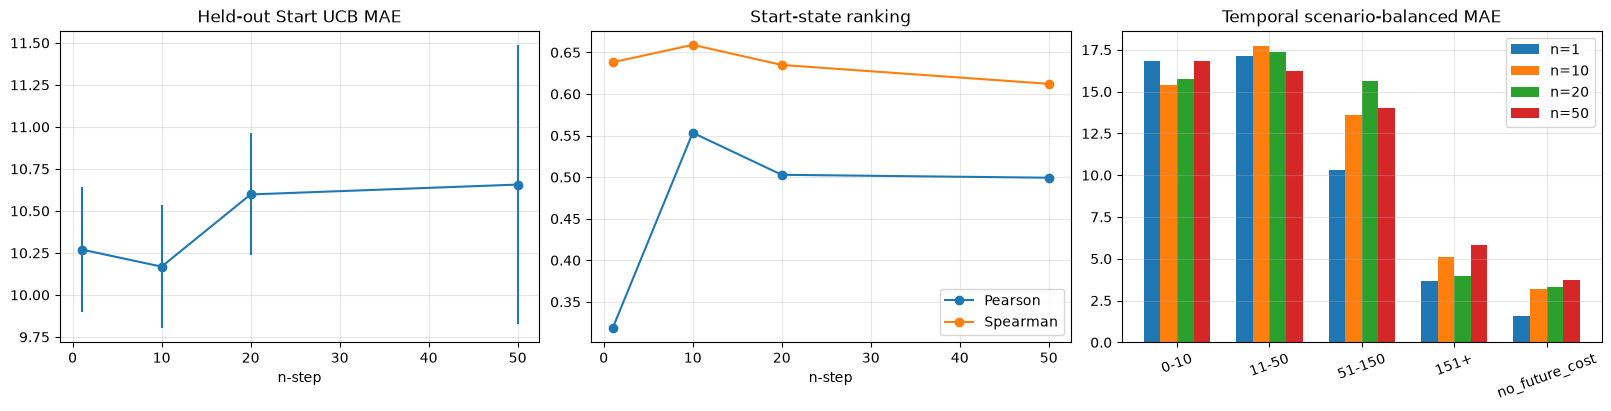

Saved: /Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/n_step_cost_propagation


In [7]:
finals={n:[all_results[(n,s)][-1] for s in COST_CRITIC_SEEDS] for n in N_STEPS}
metrics=['mae','rmse','pearson','spearman','false_negative_rate','false_positive_rate','coverage']
aggregate={}
for n,rows in finals.items():
    aggregate[str(n)]={k:{'mean':float(np.mean([r[k] for r in rows])),'median':float(np.median([r[k] for r in rows])),'values':[r[k] for r in rows]} for k in metrics}
    aggregate[str(n)]['temporal']={name:float(np.mean([r.get('temporal',{}).get(name,{}).get('scenario_balanced_mae',np.nan) for r in rows])) for name in ('0-10','11-50','51-150','151+','no_future_cost')}
report={'design':{'n_steps':N_STEPS,'seeds':COST_CRITIC_SEEDS,'updates':UPDATE_MILESTONES[-1],'training_replay':'A/C_diversity'},'aggregate':aggregate,'final_by_seed':finals}
(OUTPUT_RUN/'final_report.json').write_text(json.dumps(report,indent=2),encoding='utf-8'); display(report)
fig,axes=plt.subplots(1,3,figsize=(16,4),constrained_layout=True)
axes[0].errorbar(N_STEPS,[aggregate[str(n)]['mae']['mean'] for n in N_STEPS],yerr=[np.std(aggregate[str(n)]['mae']['values']) for n in N_STEPS],marker='o'); axes[0].set_title('Held-out Start UCB MAE')
axes[1].plot(N_STEPS,[aggregate[str(n)]['pearson']['mean'] for n in N_STEPS],marker='o',label='Pearson'); axes[1].plot(N_STEPS,[aggregate[str(n)]['spearman']['mean'] for n in N_STEPS],marker='o',label='Spearman'); axes[1].set_title('Start-state ranking'); axes[1].legend()
bins=['0-10','11-50','51-150','151+','no_future_cost']; width=.18
for j,n in enumerate(N_STEPS): axes[2].bar(np.arange(len(bins))+(j-1.5)*width,[aggregate[str(n)]['temporal'][b] for b in bins],width=width,label=f'n={n}')
axes[2].set_xticks(np.arange(len(bins)),bins,rotation=20); axes[2].set_title('Temporal scenario-balanced MAE'); axes[2].legend()
for ax in axes: ax.grid(alpha=.3); ax.set_xlabel('n-step' if ax is not axes[2] else '')
fig.savefig(OUTPUT_RUN/'n_step_comparison.png',dpi=170); plt.show(); print('Saved:',OUTPUT_RUN)